# Telco Customer Churn — Exploratory Data Analysis

Goal: Understand what drives churn through visualization. 
Each chart answers a specific business question.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
df = pd.read_pickle("../data/telco_customer_churn.pkl")

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,5)

## Visual 1: Churn distribution
Business question: How many customers are actually churning?

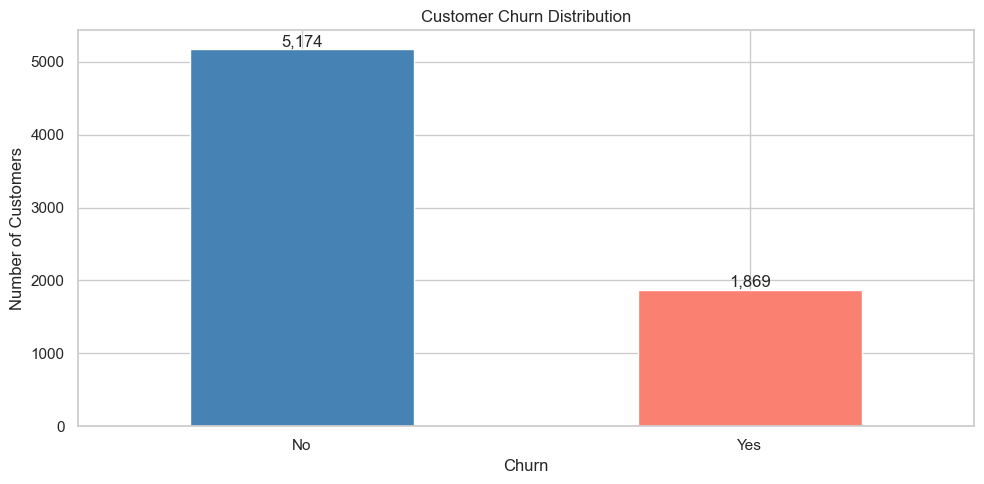

In [8]:
fig, ax = plt.subplots()

df['Churn'].value_counts().plot(kind='bar', ax=ax, color=['steelblue','salmon'])

ax.set_title('Customer Churn Distribution')
ax.set_xlabel('Churn')
ax.set_ylabel('Number of Customers')
ax.set_xticklabels(['No','Yes'], rotation=0)

for p in ax.patches:
    ax.annotate(f'{p.get_height():,}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
    
plt.tight_layout()
plt.savefig("../outputs/01_churn_distribution.png")
plt.show()

## Finding
5,174 customers stayed vs 1,869 churned — a 73.5% / 26.5% split. 
The dataset is imbalanced which means a model that predicted 
"No churn" for every customer would be 73.5% accurate but completely 
useless. We will need to account for this during modeling.

## Visual 2: Churn rate by contract type
Business question: Does the type of contract a customer has affect 
whether they churn?

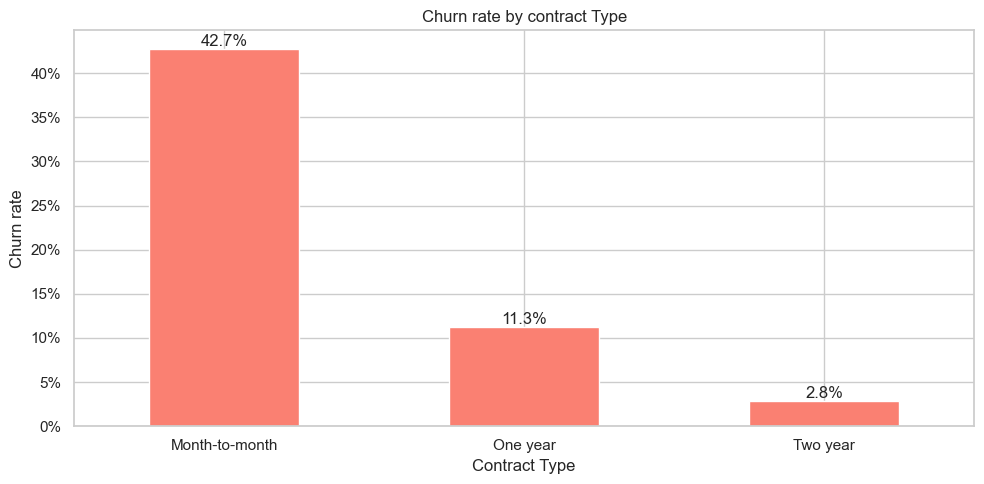

In [10]:
fig, ax = plt.subplots()

contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()

contract_churn['Yes'].sort_values(ascending=False).plot(kind='bar', ax=ax, color='salmon')

ax.set_title('Churn rate by contract Type')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Churn rate')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _:f'{y:.0%}'))

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
    
plt.tight_layout()
plt.savefig("../outputs/02_churn_by_contact.png")
plt.show()

## Finding
Contract type is a significant predictor of churn in this dataset.
Month-to-month customers churn at 42.7% — over 15x the rate of two-year 
contract customers at 2.8%. One-year contracts sit in the middle at 11.3%.

Business implication: Converting month-to-month customers to longer 
contracts is likely the highest-impact retention strategy available. 
Even moving a customer from month-to-month to a one-year contract 
reduces their churn risk by 75%.

## Visual 3: Tenure distribution by churn
Business question: Do newer customers churn more than long-term customers?

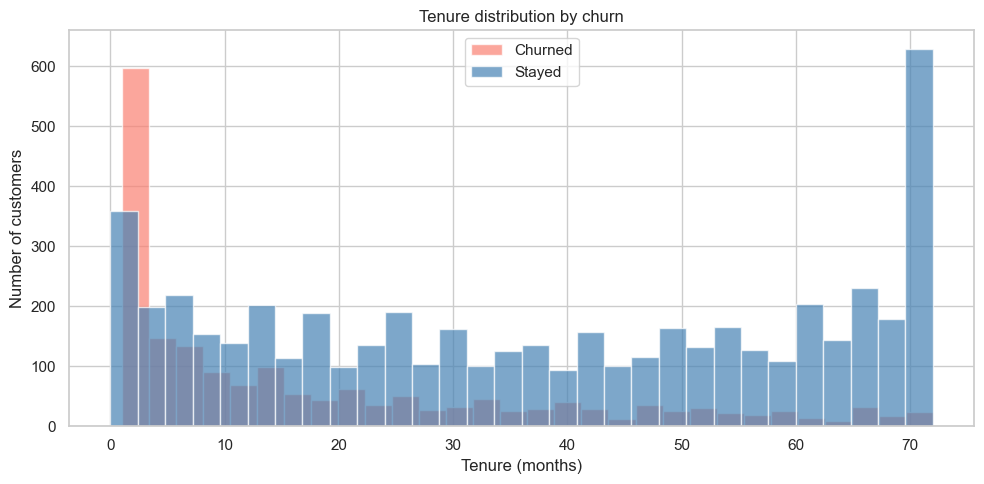

In [11]:
fig, ax = plt.subplots()

df[df['Churn'] == 'Yes']['tenure'].hist(bins=30, ax=ax, alpha=0.7, color='salmon', label='Churned')
df[df['Churn'] == 'No']['tenure'].hist(bins=30, ax=ax, alpha=0.7, color='steelblue', label='Stayed')

ax.set_title('Tenure distribution by churn')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Number of customers')
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/03_tenure_by_churn.png")
plt.show()

## Finding
Churn is heavily concentrated in the first 1-2 months of a customer's 
lifecycle. The salmon bars almost disappear after month 10, meaning 
customers who survive the first year are very likely to stay long term.

The spike of stayed customers at 70+ months shows a loyal base of 
long-tenured customers who almost never churn.

Business implication: The first 90 days are the highest-risk window. 
Onboarding programs and early intervention strategies should be 
prioritized for new customers.

## Visual 4: Monthly charges by churn
Business question: Do customers who pay more churn at a higher rate?

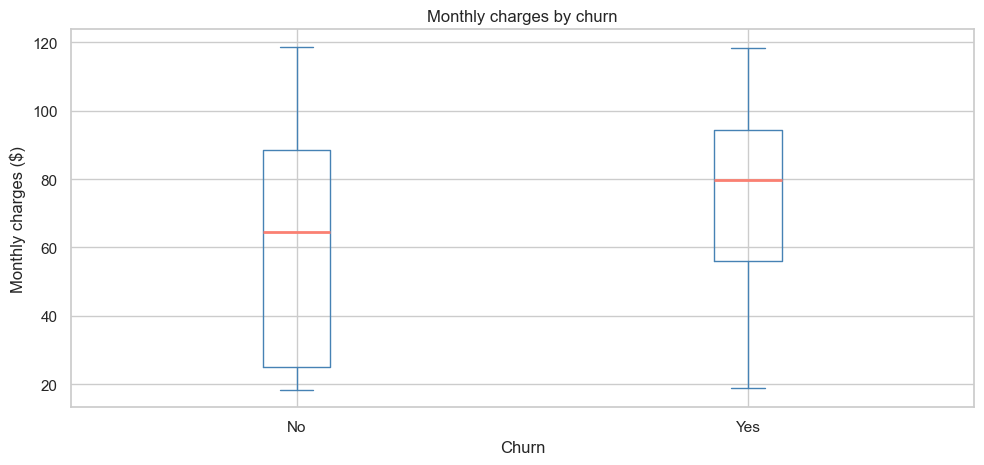

Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64


In [ ]:
fig, ax = plt.subplots()

df.boxplot(column='MonthlyCharges', by='Churn', ax=ax,
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='salmon', linewidth=2),
           whiskerprops=dict(color='steelblue'),
           capprops=dict(color='steelblue'))

ax.set_title('Monthly charges by churn')
ax.set_xlabel('Churn')
ax.set_ylabel('Monthly charges ($)')
plt.suptitle('')

plt.tight_layout()
plt.savefig("../outputs/04_monthly_charges_by_churn.png")
plt.show()


print(df.groupby('Churn')['MonthlyCharges'].mean().round(2))

## Finding
Customers who churned paid on average $74.44/month compared to $61.27 
for customers who stayed — a $13.17 difference.


## Visual 5: Correlation heatmap of numeric features
Business question: How do the numeric features relate to each other?

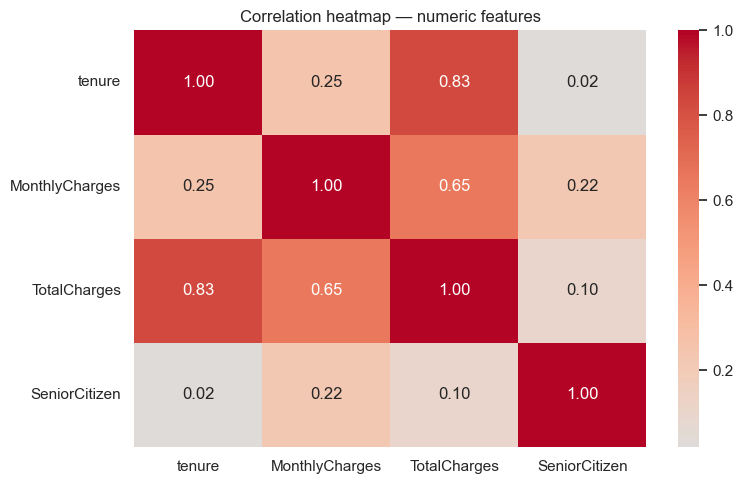

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

numeric_cols = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']]

sns.heatmap(numeric_cols.corr().round(2), 
            annot=True, 
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            ax=ax)

ax.set_title('Correlation heatmap — numeric features')

plt.tight_layout()
plt.savefig("../outputs/05_correlation_heatmap.png")
plt.show()

## Finding
Two correlations stand out:

1. tenure and TotalCharges: 0.83 — very high. This makes logical sense 
because TotalCharges = tenure × MonthlyCharges. The longer a customer 
stays, the more total they have paid. These two features carry overlapping 
information.

2. MonthlyCharges and TotalCharges: 0.65 — also high for the same reason.

Modeling implication: TotalCharges is largely redundant when we already 
have tenure and MonthlyCharges. We will consider dropping TotalCharges 
during preprocessing to avoid multicollinearity, which can distort 
logistic regression coefficients.

## Visual 6: Feature correlation with churn
Business question: Which numeric features are most strongly associated 
with whether a customer churns?

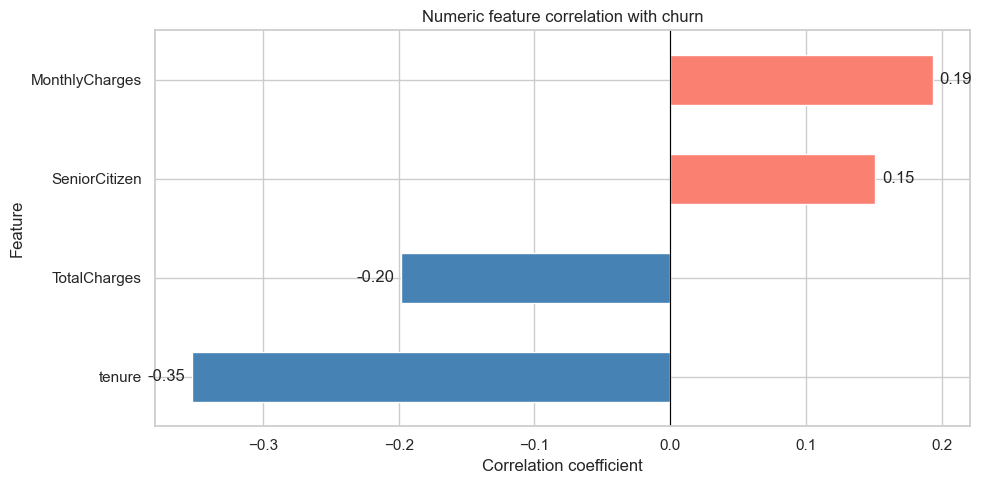

tenure           -0.352
TotalCharges     -0.198
SeniorCitizen     0.151
MonthlyCharges    0.193
dtype: float64


In [14]:
churn_binary = df['Churn'].map({'Yes': 1, 'No': 0})

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
correlations = df[numeric_cols].corrwith(churn_binary).sort_values()

fig, ax = plt.subplots()

colors = ['salmon' if c > 0 else 'steelblue' for c in correlations]

correlations.plot(kind='barh', ax=ax, color=colors)

ax.set_title('Numeric feature correlation with churn')
ax.set_xlabel('Correlation coefficient')
ax.set_ylabel('Feature')
ax.axvline(x=0, color='black', linewidth=0.8)

for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}',
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left' if p.get_width() > 0 else 'right',
                va='center',
                xytext=(5 if p.get_width() > 0 else -5, 0),
                textcoords='offset points')

plt.tight_layout()
plt.savefig("../outputs/06_feature_correlation_churn.png")
plt.show()

print(correlations.round(3))

## Finding
Tenure has the strongest relationship with churn at -0.35 — the negative 
sign means longer-tenured customers are less likely to churn. This is the 
most predictive numeric feature we have.

MonthlyCharges shows a positive correlation of 0.19 — higher bills are 
associated with higher churn risk, confirming what we saw in visual 4.

TotalCharges is negative at -0.20 which seems contradictory to 
MonthlyCharges being positive. This is explained by multicollinearity — 
TotalCharges is driven heavily by tenure, so its negative correlation 
reflects tenure's effect more than the charges themselves. This further 
supports dropping TotalCharges in preprocessing.

SeniorCitizen at 0.15 shows senior customers churn at a slightly higher 
rate — a smaller but real signal worth keeping as a feature.


## Visual 7: Churn rate by categorical features
Business question: Which categorical features are most associated with churn?

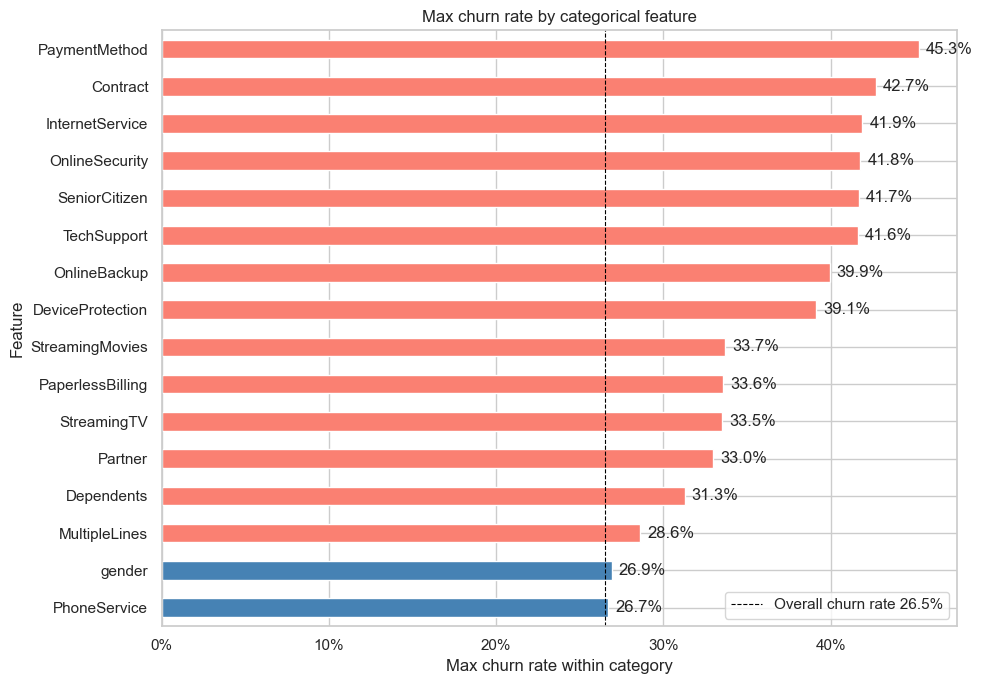

PaymentMethod       0.453
Contract            0.427
InternetService     0.419
OnlineSecurity      0.418
SeniorCitizen       0.417
TechSupport         0.416
OnlineBackup        0.399
DeviceProtection    0.391
StreamingMovies     0.337
PaperlessBilling    0.336
StreamingTV         0.335
Partner             0.330
Dependents          0.313
MultipleLines       0.286
gender              0.269
PhoneService        0.267
dtype: float64


In [15]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 
            'PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

churn_rates = {}
for col in cat_cols:
    rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x)
    ).max()  # take the highest churn rate within that feature
    churn_rates[col] = rate


churn_rates = pd.Series(churn_rates).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

colors = ['salmon' if c > 0.27 else 'steelblue' for c in churn_rates]

churn_rates.plot(kind='barh', ax=ax, color=colors)

ax.set_title('Max churn rate by categorical feature')
ax.set_xlabel('Max churn rate within category')
ax.set_ylabel('Feature')
ax.axvline(x=0.265, color='black', linewidth=0.8, linestyle='--', 
           label='Overall churn rate 26.5%')
ax.legend()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

for p in ax.patches:
    ax.annotate(f'{p.get_width():.1%}',
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center',
                xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.savefig("../outputs/07_categorical_churn_rates.png")
plt.show()

print(churn_rates.sort_values(ascending=False).round(3))

## Finding
Almost every categorical feature shows above-average churn in at least 
one of its categories — meaning nearly all of them carry useful signal 
for the model.

Bottom features — closest to the overall churn rate:
- PhoneService: 26.7% — barely above average, weak signal
- gender: 26.9% — essentially no difference, likely safe to drop

## Visual 8: Churn rate by payment method
Business question: Which payment methods are associated with higher churn?

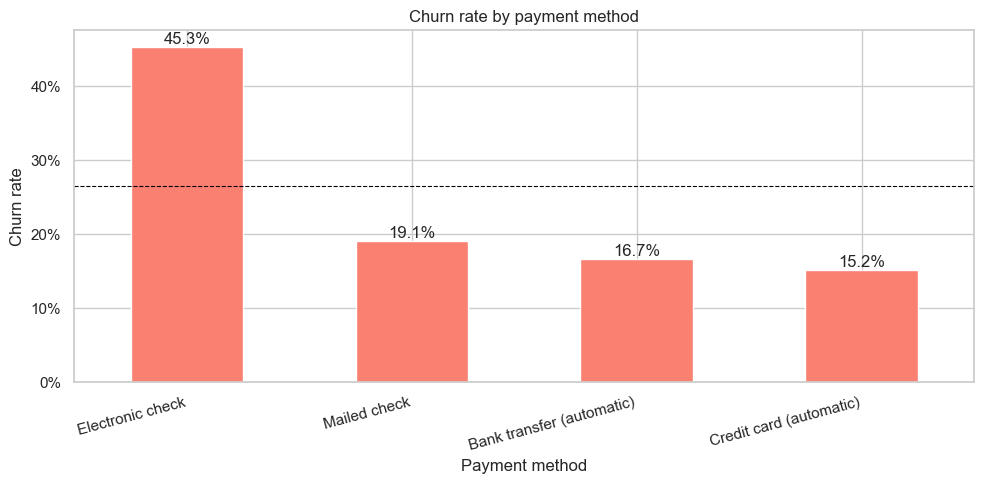

PaymentMethod              Churn
Bank transfer (automatic)  No       1286
                           Yes       258
Credit card (automatic)    No       1290
                           Yes       232
Electronic check           No       1294
                           Yes      1071
Mailed check               No       1304
                           Yes       308
Name: count, dtype: int64


In [17]:
fig, ax = plt.subplots()

payment_churn = df.groupby('PaymentMethod')['Churn'].value_counts(
    normalize=True).unstack()

payment_churn['Yes'].sort_values(ascending=False).plot(
    kind='bar', ax=ax, color='salmon'
)

ax.set_title('Churn rate by payment method')
ax.set_xlabel('Payment method')
ax.set_ylabel('Churn rate')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.axhline(y=0.265, color='black', linewidth=0.8, linestyle='--',
           label='Overall churn rate 26.5%')
ax.legend()

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1%}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

ax.get_legend().remove()
plt.tight_layout()
plt.savefig("../outputs/08_churn_by_payment_method.png")
plt.show()


print(df.groupby('PaymentMethod')['Churn'].value_counts())